# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file

In [2]:
# parameters of the simulation
par={'L': 10,                    # side length of the squared lattice
     'p_self_link': 0,         # probability for each cell of having a self link
     'C_density': 0.5,                       # initial density of links
     'J_range': [-1,+1],                       # define the possible value for J.
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'T_crossover_ratio': 0.1,                    # percentage of offspring to be generated by crossover + mutation (instead of only mutation)
     #'target_set': [0.0,1.0,1.0,0.0],
     'target_set': [-2,+2,+2,-2],
     #'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'input_set':[[-2,-2],[-2,+2],[+2,-2],[+2,+2]],
     'ff_iter': 10,                               # number of iterations the ff is executed for computing the output of a network (to reach the steady state)
     'state_bound': [-10,+10],                    # boundaries on the possibile values of the state
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.5,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 2,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'x_n': np.linspace(-1,1,64),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'n_iter': 10,
     'N_sol': 4}                       # number of solutions (individuals, networks) considered in the simulation

#nrd.seed(1234)

In [3]:
solutions, lmean, t_dist_mean, volume_mean = m.evolution(par,verb=3,gen_verb=False)

Iteration #0...
Mean loss: 8.823339273807681
Mean target distance: 31.730823393616962
Mean link: 3.141618831959527
Iteration #1...
Mean loss: 7.369798580961665
Mean target distance: 31.320482542458876
Mean link: 2.78110150783111
Iteration #2...
Mean loss: 4.877092982948277
Mean target distance: 21.729873530361722
Mean link: 2.6730755524807406
Iteration #3...
Mean loss: 6.002713972573441
Mean target distance: 22.427199726921057
Mean link: 2.6687430135011883
Iteration #4...
Mean loss: 5.191936018608957
Mean target distance: 24.648370816522057
Mean link: 2.638551893286045
Iteration #5...
Mean loss: 5.195410096044389
Mean target distance: 18.89457786560116
Mean link: 2.6728836255604977
Iteration #6...
Mean loss: 5.190635029106456
Mean target distance: 23.30078466595485
Mean link: 2.6694917391889046
Iteration #7...
Mean loss: 5.800567259924275
Mean target distance: 29.670406116118595
Mean link: 2.8563570169291355
Iteration #8...
Mean loss: 6.403392939768253
Mean target distance: 20.88091431

In [4]:
print(f'# parents: {int(np.floor(par['N_sol'] * par['reproduction_ratio'])-np.floor(par['N_sol'] * par['reproduction_ratio'])%2)}')

# parents: 2


In [5]:
s = copy.deepcopy(solutions)
losses = []
for n,sol in enumerate(s[:20]):
    print(f'Solution #{n}')
    loss,_,_ = m.compute_loss(sol,par,verb=True)
    losses.append(loss)
    print(f'loss:{loss}')

Solution #0
Input: [-2, -2] -> Output: 0.25083402844229347
Target distance:2.2508340284422936
Link cost:0.009751550458197191
Input: [-2, 2] -> Output: -2.2901569390465037
Target distance:4.290156939046504
Link cost:0.009751550458197191
Input: [2, -2] -> Output: 0.250834028442295
Target distance:1.749165971557705
Link cost:0.009751550458197191
Input: [2, 2] -> Output: -2.2901569390465037
Target distance:0.29015693904650375
Link cost:0.009751550458197191
loss:2.1450784695232517
Solution #1
Input: [-2, -2] -> Output: 10.0
Target distance:12.0
Link cost:1.2926772438629819
Input: [-2, 2] -> Output: -10.0
Target distance:12.0
Link cost:1.2926772438629819
Input: [2, -2] -> Output: 4.943524034330014
Target distance:2.9435240343300144
Link cost:1.2926772438629819
Input: [2, 2] -> Output: -10.0
Target distance:8.0
Link cost:1.2926772438629819
loss:8.735881008582503
Solution #2
Input: [-2, -2] -> Output: 10.0
Target distance:12.0
Link cost:1.3138842707698963
Input: [-2, 2] -> Output: 10.0
Target 

In [6]:
print(f'Mean final loss: {np.mean(np.array(losses) < 100)}')

Mean final loss: 1.0


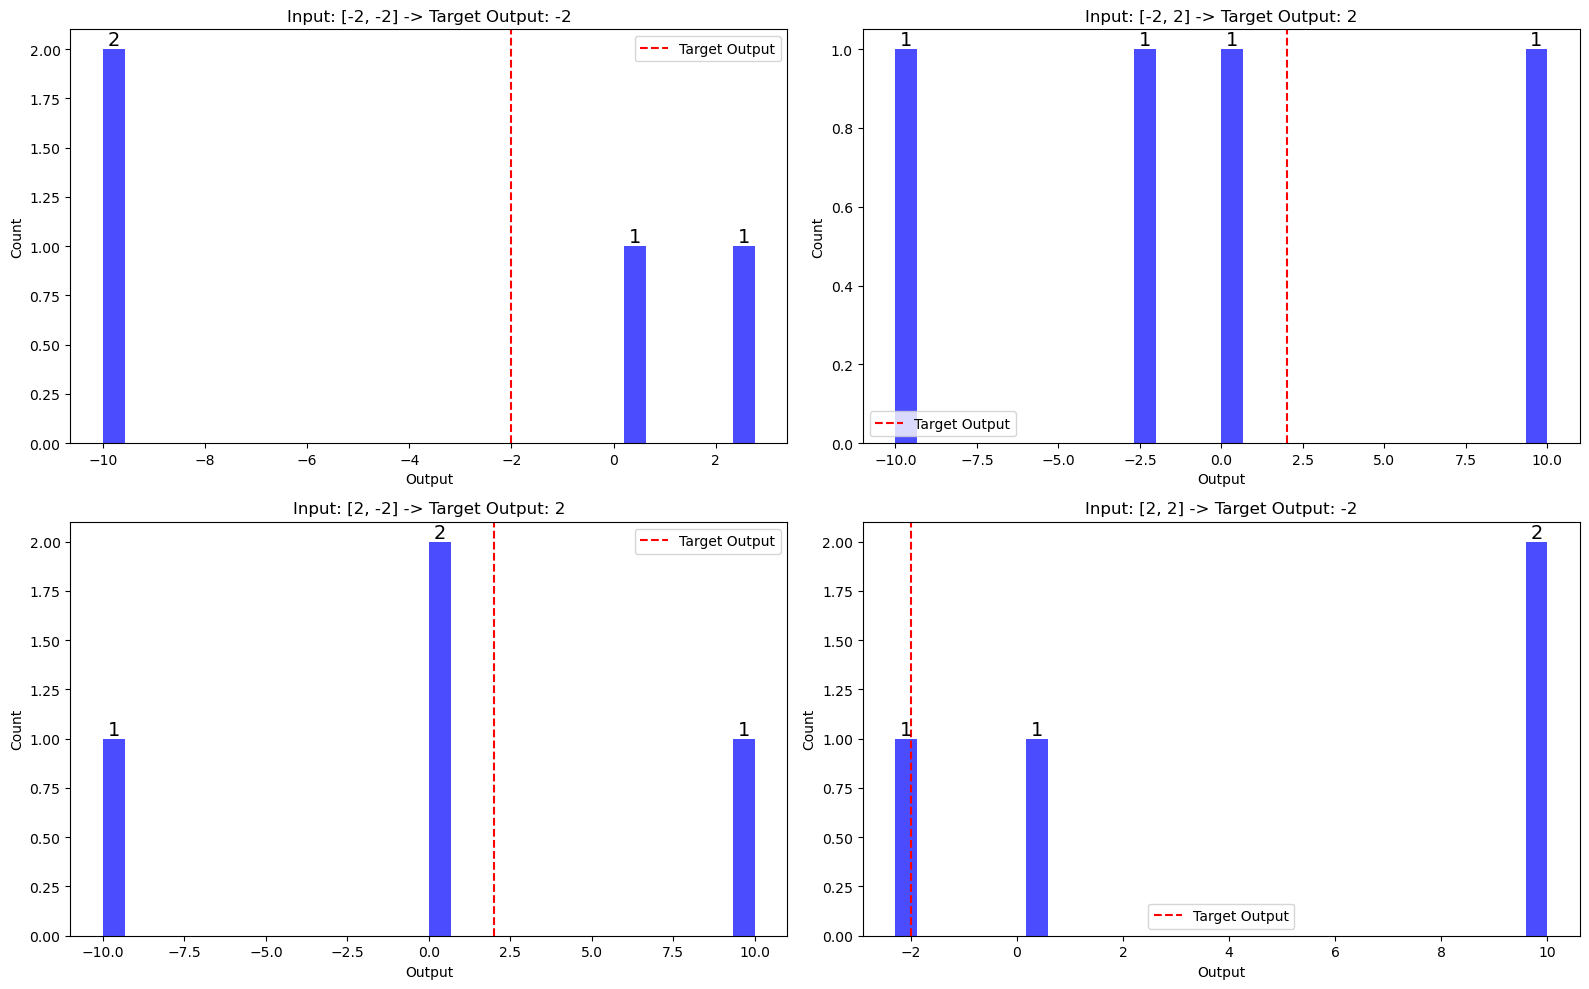

In [7]:
outputs = np.zeros((len(solutions),len(par['input_set'])))
for n,sol in enumerate(solutions):
    for i,input in enumerate(par['input_set']):
        output = m.ff(input,sol,par)
        outputs[n,i] = output

fig, axes = plt.subplots(2, len(par['input_set'])//2, figsize=(16, 10))
axes = axes.flatten()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=30, alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]} -> Target Output: {par['target_set'][i]}')
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.axvline(par['target_set'][i], label='Target Output', color='r',linestyle='--')
    #ax.set_xticks(list(ax.get_xticks()) + [par['target_set'][i]])
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}', 
                        (patch.get_x() + patch.get_width() / 2, height), 
                        ha='center', va='bottom', fontsize=14)
    ax.legend()
plt.tight_layout()
plt.show()

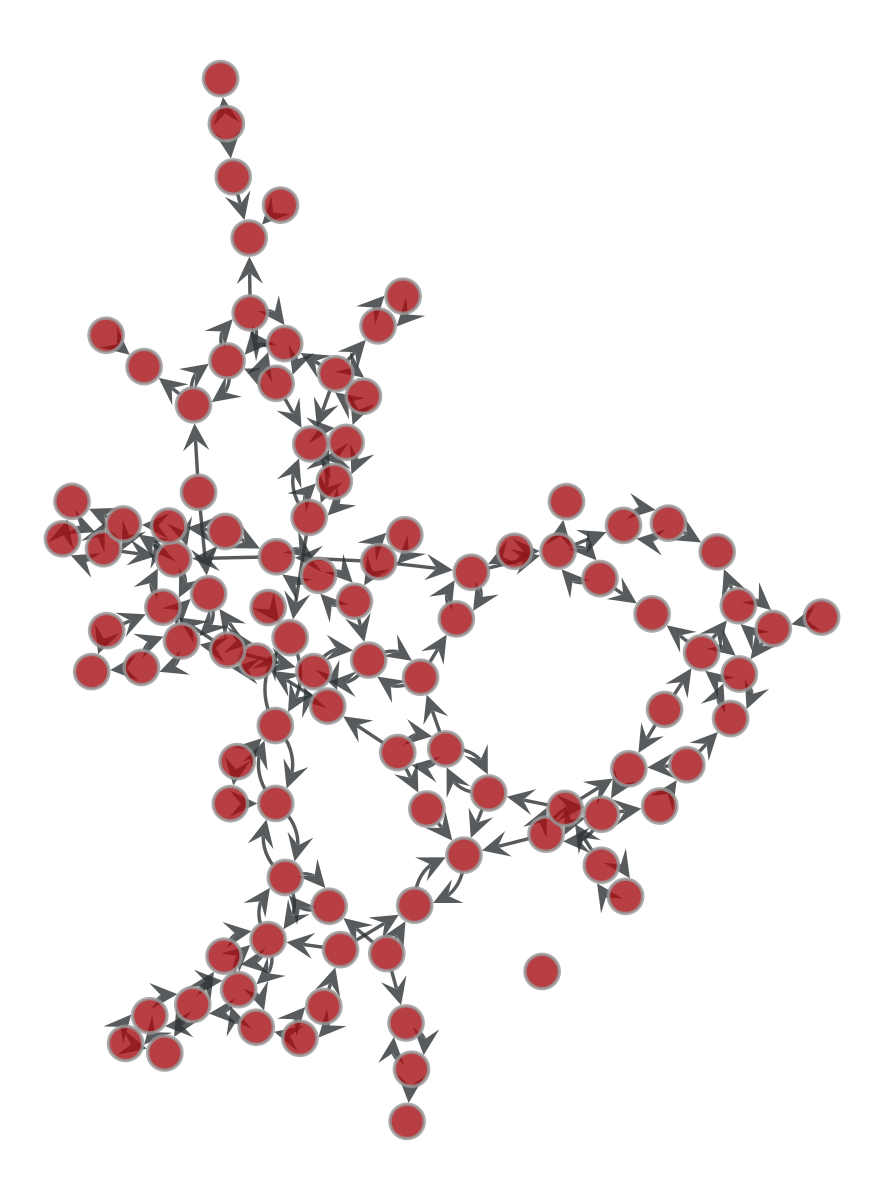

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7fe17cd2e210, at 0x7fe1743c4280>

In [8]:
graph_draw(s[0].G)

In [9]:
print(f'Percentage of links over the maximum possible:{np.sum(s[0].C)/s[0].C.shape[0]**2}')

Percentage of links over the maximum possible:0.0176


In [10]:
np.array([sol.loss for sol in s])

array([ 2.14507819, 11.        ,  7.1009328 ,  1.95327039])

In [11]:
input = [-2,2]
_,state = m.ff(input, s[2],par,verb=2)
print(f'State:{state}')

State:[-2.00000000e+00 -1.00000000e+01  3.16645097e+00 -1.00000000e+01
  1.00000000e+01 -1.00000000e+01 -1.00000000e+01 -1.00000000e+01
  1.00000000e+01  1.00000000e+01 -1.00000000e+01 -1.00000000e+01
 -1.00000000e+01  1.00000000e+01 -1.00000000e+01 -9.79649644e+00
 -1.00000000e+01  1.00000000e+01  1.00000000e+01  2.14896053e+00
  1.00000000e+01 -1.00000000e+01  1.00000000e+01  7.90874711e-03
 -1.00000000e+01 -1.00000000e+01 -1.00000000e+01 -1.00000000e+01
 -1.00000000e+01 -1.00000000e+01 -1.54653136e+00  1.00000000e+01
  9.32244206e+00  2.55619052e+00  1.00000000e+01  3.71053873e-02
 -1.00000000e+01  4.10129863e+00  1.00000000e+01  1.00000000e+01
  1.00000000e+01  1.00000000e+01  1.00000000e+01  1.00000000e+01
  1.00000000e+01 -1.00000000e+01 -1.00000000e+01  7.27552097e+00
  1.00000000e+01 -1.00000000e+01 -1.00000000e+01  1.60690104e-02
  1.00000000e+01  1.00000000e+01  1.00000000e+01 -1.00000000e+01
 -1.00000000e+01  1.00000000e+01  1.00000000e+01  1.00000000e+01
 -1.00000000e+01  1

In [12]:
for input in par['input_set']:
    output,_ = m.ff(input,s[0],par,verb=2)
    print(f'Input:{input} -> Output:{output}')

Input:[-2, -2] -> Output:0.2508340284422723
Input:[-2, 2] -> Output:-2.2901569390465037
Input:[2, -2] -> Output:0.25083402844227204
Input:[2, 2] -> Output:-2.2901548153760793


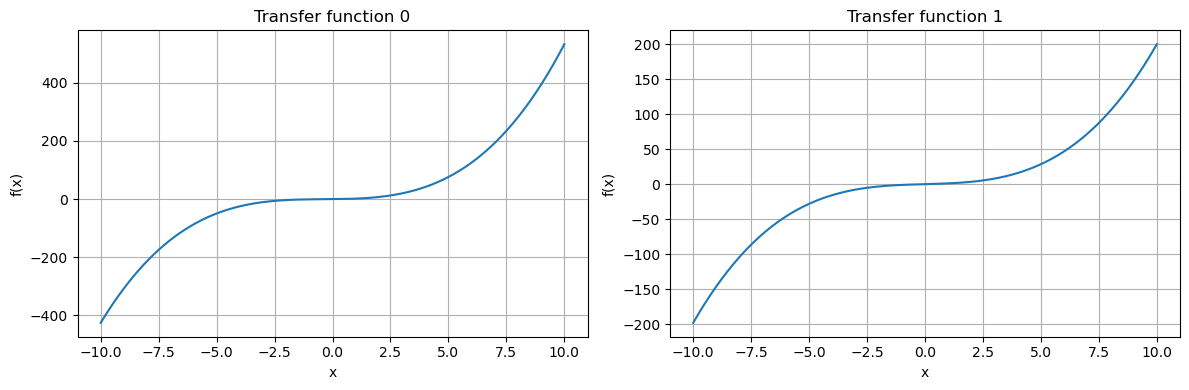

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(2):
    f_n = np.fft.irfft(solutions[0].T[i])
    coeff = np.polyfit(par['x_n'], f_n, 3)
    new_fun = np.poly1d(coeff)
    x = np.linspace(min(par['x_n']), max(par['x_n']), 1000)
    x = np.linspace(-10, 10, 1000)
    axes[i].plot(x, new_fun(x))
    axes[i].grid()
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].set_title(f'Transfer function {i}')
plt.tight_layout()
plt.show()

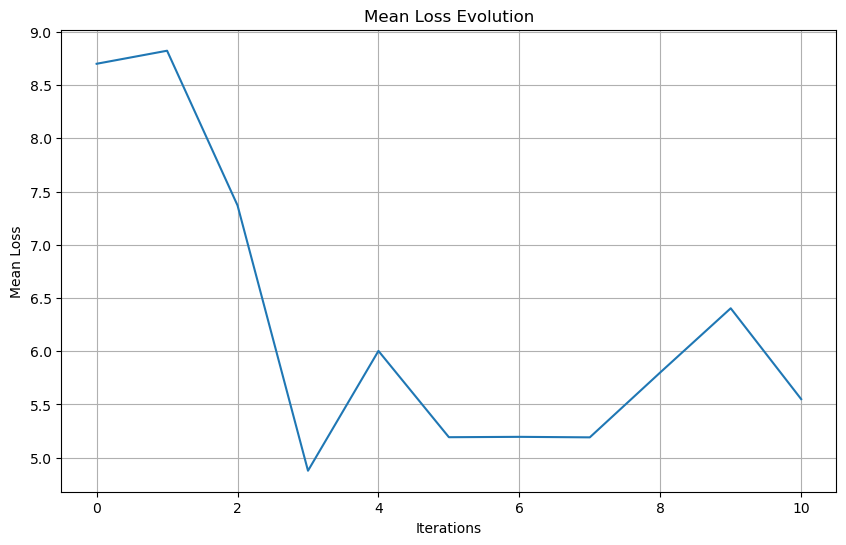

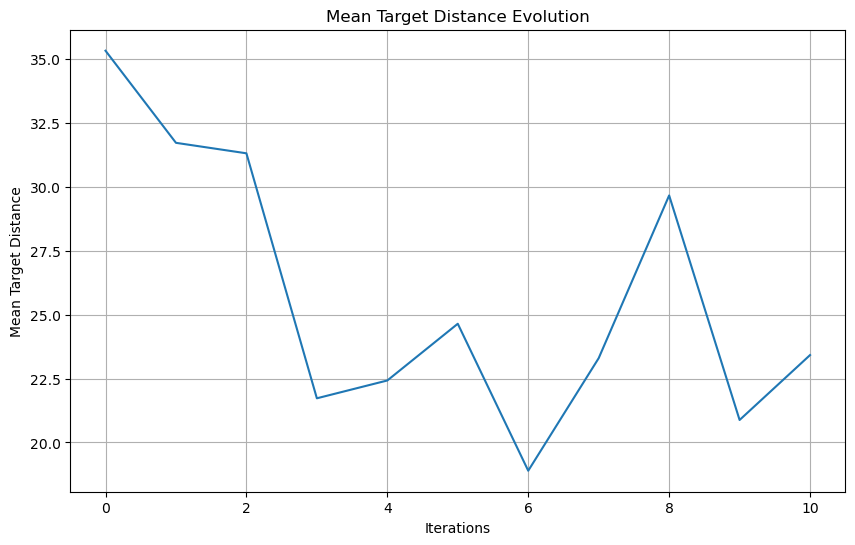

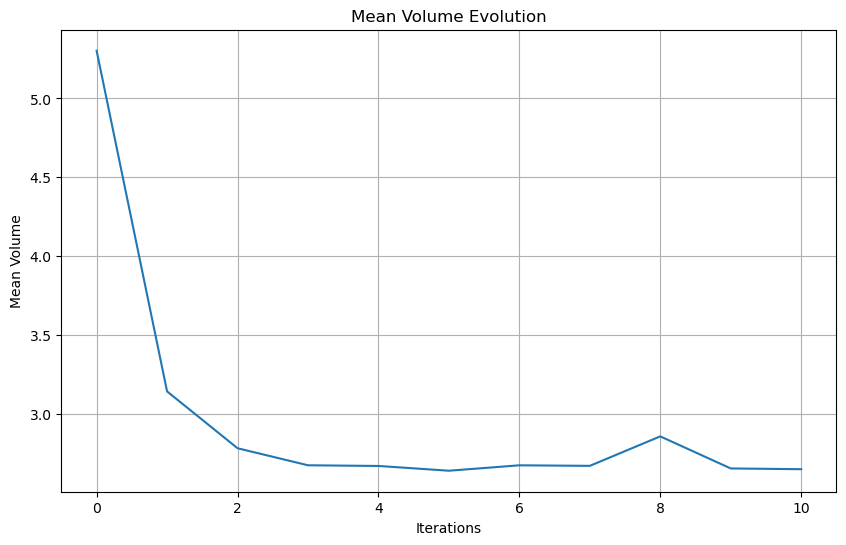

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(lmean)
plt.title('Mean Loss Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Loss')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_dist_mean)
plt.title('Mean Target Distance Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Target Distance')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(volume_mean)
plt.title('Mean Volume Evolution')
plt.xlabel('Iterations')
plt.ylabel('Mean Volume')
#plt.yscale('log')
#plt.xscale('log')
plt.grid(True)
plt.show()